In [ ]:
logging.set_verbosity_error()
logging.disable_progress_bar()

In [21]:
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
import torch
import time
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

_MODEL_CACHE = {}

def _load(model_name):
    if model_name not in _MODEL_CACHE:
        tok = AutoTokenizer.from_pretrained(model_name)
        mdl = AutoModelForCausalLM.from_pretrained(model_name)
        _MODEL_CACHE[model_name] = (tok, mdl)
    return _MODEL_CACHE[model_name]

def drift_sentence_meaning(model_name, phrase, target_word, changed_index, n_steps=101, thresh=0.10):
    tokenizer, model = _load(model_name)
    embedding_layer = model.get_input_embeddings()

    def word_embedding(w):
        ids = tokenizer.encode(" " + w)
        if len(ids) != 1:
            print(f"warning: {w!r} -> {len(ids)} tokens, using first")
        return embedding_layer.weight[ids[0]]

    inputs = tokenizer(phrase, return_tensors="pt")
    attn = inputs["attention_mask"]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    print("tokens:", list(enumerate(tokens)))

    base_embeds = embedding_layer(inputs["input_ids"]).detach()
    original_vec = base_embeds[0, changed_index, :].clone()
    target_vec = word_embedding(target_word)
    morph_word = tokenizer.decode([int(inputs["input_ids"][0][changed_index])]).strip()

    top5_by_step, transitions, prev_top = {}, [], None
    for i, alpha in enumerate(torch.linspace(0, 1, n_steps)):
        embeds = base_embeds.clone()
        embeds[0, changed_index, :] = (1 - alpha) * original_vec + alpha * target_vec
        with torch.no_grad():
            logits = model(inputs_embeds=embeds, attention_mask=attn).logits
        probs = torch.softmax(logits[0, -1, :], dim=-1)
        top5 = torch.topk(probs, 5)
        top5_by_step[i] = top5
        pred = tokenizer.decode(top5.indices[0]).strip()
        if prev_top is not None and pred != prev_top:
            transitions.append((i / (n_steps - 1), prev_top, pred))
        prev_top = pred

    start_top = tokenizer.decode(top5_by_step[0].indices[0]).strip()
    end_top = tokenizer.decode(top5_by_step[n_steps - 1].indices[0]).strip()
    print(f"\nmorphing {morph_word!r} -> {target_word!r}")
    print(f"  alpha=0.00   {start_top!r}")
    for a, frm, to in transitions:
        print(f"  alpha={a:.2f}   {frm!r} -> {to!r}")
    print(f"  alpha=1.00   {end_top!r}")
    print(f"  {len(transitions)} change(s) across the sweep")

    steps = sorted(top5_by_step)
    alphas = np.array([i / (n_steps - 1) for i in steps])
    per_step = {i: {idx.item(): p.item()
                    for p, idx in zip(top5_by_step[i].values, top5_by_step[i].indices)}
                for i in steps}
    all_ids = {t for d in per_step.values() for t in d}

    fallback = cycle(plt.get_cmap("tab10").colors)
    color_by_id = {}
    for t in sorted(all_ids):
        w = tokenizer.decode(t).strip().lower()
        color_by_id[t] = ("dimgray" if w == "black"
                        else w if w in mcolors.CSS4_COLORS else next(fallback))

    fig, ax = plt.subplots(figsize=(10, 6))
    for t in all_ids:
        probs = [per_step[i].get(t, float("nan")) for i in steps]
        ax.plot(alphas, probs, marker=".", color=color_by_id[t],
                label=repr(tokenizer.convert_ids_to_tokens([t])[0]))
    for a, *_ in transitions:
        ax.axvline(a, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("alpha (0 = original, 1 = target)")
    ax.set_ylabel("probability")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    band = {t: np.array([per_step[i].get(t, 0.0) for i in steps]) for t in all_ids}
    keep = sorted((t for t in all_ids if band[t].max() >= thresh),
                  key=lambda t: int(np.argmax(band[t])))
    if not keep:
        keep = sorted(all_ids, key=lambda t: -band[t].max())[:5]
        keep = sorted(keep, key=lambda t: int(np.argmax(band[t])))
    M = np.vstack([band[t] for t in keep])
    other = 1 - M.sum(axis=0)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.stackplot(alphas, *M, other,
                 labels=[tokenizer.decode(t).strip().lower() for t in keep] + ["other"],
                 colors=[color_by_id[t] for t in keep] + ["lightgray"])
    for a, *_ in transitions:
        ax.axvline(a, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("alpha (0 = original, 1 = target)")
    ax.set_ylabel("probability")
    ax.set_xlim(alphas[0], alphas[-1]); ax.set_ylim(0, 1)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.tight_layout(); plt.show()

    return top5_by_step, transitions

## We can see the models' outputs change as the other context of the contronym becomes more apparent. 

tokens: [(0, 'government'), (1, 'Ġsanctioned'), (2, 'Ġthe'), (3, 'Ġuse'), (4, 'Ġof'), (5, 'Ġthe')]

morphing 'government' -> 'I'
  alpha=0.00   'drug'
  alpha=0.22   'drug' -> 'term'
  alpha=1.00   'term'
  1 change(s) across the sweep


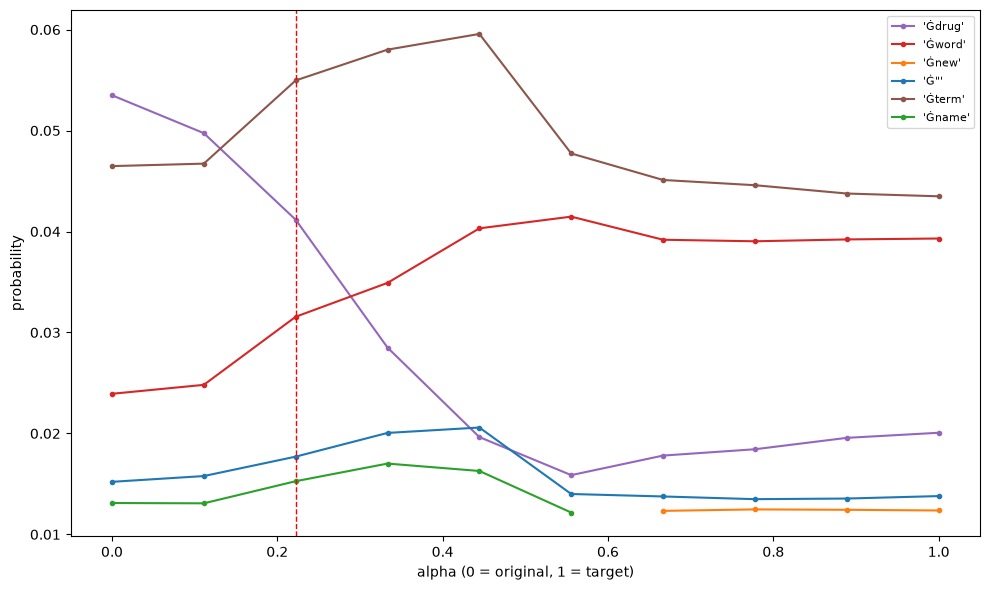

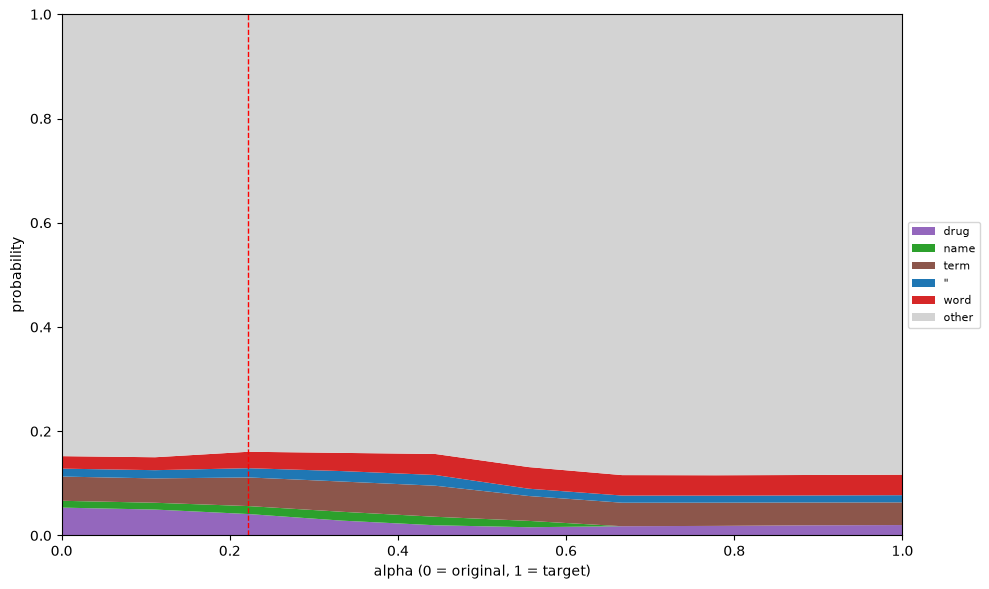

({0: torch.return_types.topk(
  values=tensor([0.0535, 0.0465, 0.0239, 0.0152, 0.0131], dtype=torch.float16),
  indices=tensor([2563, 3381, 1573,  366, 1438])),
  1: torch.return_types.topk(
  values=tensor([0.0497, 0.0467, 0.0248, 0.0158, 0.0131], dtype=torch.float16),
  indices=tensor([2563, 3381, 1573,  366, 1438])),
  2: torch.return_types.topk(
  values=tensor([0.0550, 0.0412, 0.0316, 0.0177, 0.0153], dtype=torch.float16),
  indices=tensor([3381, 2563, 1573,  366, 1438])),
  3: torch.return_types.topk(
  values=tensor([0.0580, 0.0349, 0.0285, 0.0201, 0.0170], dtype=torch.float16),
  indices=tensor([3381, 1573, 2563,  366, 1438])),
  4: torch.return_types.topk(
  values=tensor([0.0596, 0.0403, 0.0206, 0.0196, 0.0163], dtype=torch.float16),
  indices=tensor([3381, 1573,  366, 2563, 1438])),
  5: torch.return_types.topk(
  values=tensor([0.0477, 0.0415, 0.0159, 0.0140, 0.0122], dtype=torch.float16),
  indices=tensor([3381, 1573, 2563,  366, 1438])),
  6: torch.return_types.topk(
  va

In [24]:
drift_sentence_meaning("microsoft/phi-2", "government sanctioned the use of the", "I", changed_index=0, n_steps=10) # n_steps=10 to save time for the same results

tokens: [(0, 'government'), (1, 'Ġsanctioned'), (2, 'Ġthe'), (3, 'Ġuse'), (4, 'Ġof'), (5, 'Ġthe')]

morphing 'government' -> 'I'
  alpha=0.00   'military'
  alpha=0.14   'military' -> 'term'
  alpha=0.98   'term' -> 'word'
  alpha=1.00   'word'
  2 change(s) across the sweep


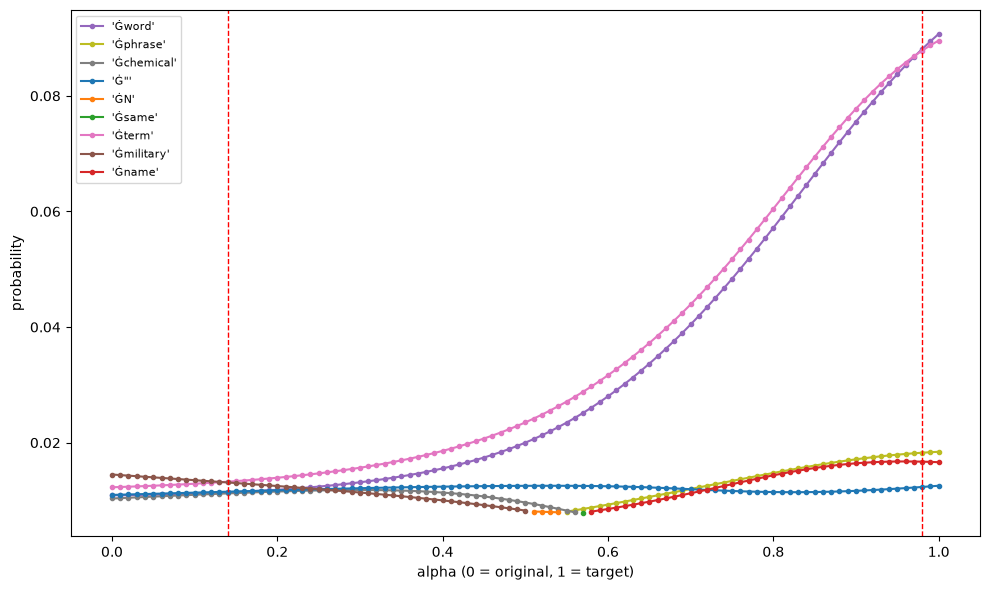

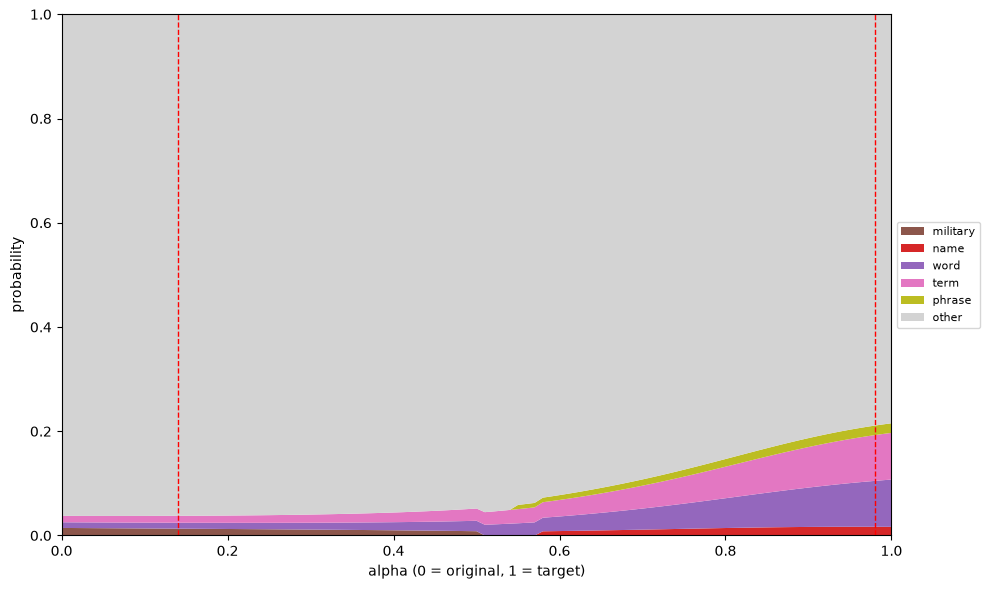

({0: torch.return_types.topk(
  values=tensor([0.0145, 0.0123, 0.0110, 0.0109, 0.0103]),
  indices=tensor([2422, 3381,  366, 1573, 5931])),
  1: torch.return_types.topk(
  values=tensor([0.0144, 0.0123, 0.0110, 0.0109, 0.0104]),
  indices=tensor([2422, 3381,  366, 1573, 5931])),
  2: torch.return_types.topk(
  values=tensor([0.0143, 0.0124, 0.0110, 0.0109, 0.0105]),
  indices=tensor([2422, 3381,  366, 1573, 5931])),
  3: torch.return_types.topk(
  values=tensor([0.0142, 0.0124, 0.0111, 0.0109, 0.0105]),
  indices=tensor([2422, 3381,  366, 1573, 5931])),
  4: torch.return_types.topk(
  values=tensor([0.0141, 0.0125, 0.0111, 0.0110, 0.0106]),
  indices=tensor([2422, 3381,  366, 1573, 5931])),
  5: torch.return_types.topk(
  values=tensor([0.0140, 0.0125, 0.0112, 0.0110, 0.0107]),
  indices=tensor([2422, 3381,  366, 1573, 5931])),
  6: torch.return_types.topk(
  values=tensor([0.0139, 0.0126, 0.0112, 0.0110, 0.0107]),
  indices=tensor([2422, 3381,  366, 1573, 5931])),
  7: torch.return_ty

In [22]:
drift_sentence_meaning("gpt2", "government sanctioned the use of the", "I", changed_index=0)

tokens: [(0, 'Having'), (1, 'Ġoverlooked'), (2, 'Ġa'), (3, 'Ġsignificant'), (4, 'Ġmistake'), (5, ','), (6, 'ĠI'), (7, 'Ġfelt'), (8, 'Ġsuper')]

morphing 'mistake' -> 'project'
  alpha=0.00   'embarrassed'
  alpha=0.44   'embarrassed' -> 'guilty'
  alpha=1.00   'guilty'
  1 change(s) across the sweep


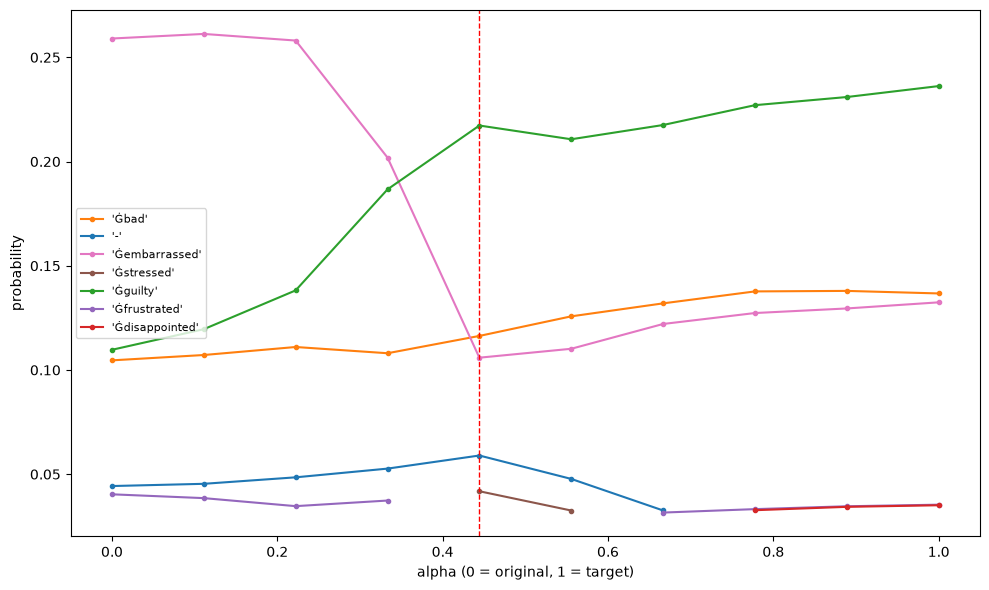

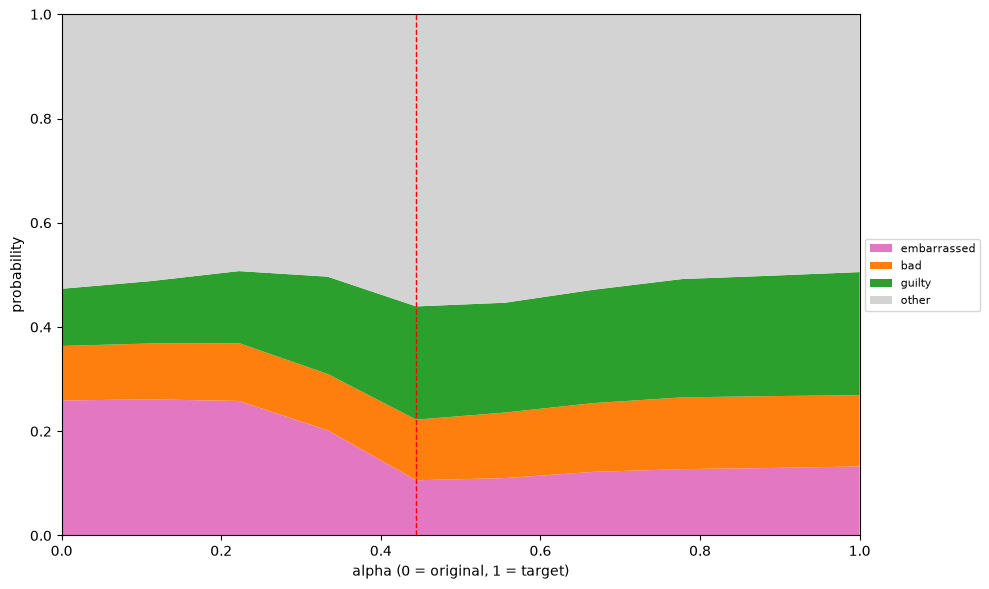

({0: torch.return_types.topk(
  values=tensor([0.2590, 0.1097, 0.1046, 0.0443, 0.0403], dtype=torch.float16),
  indices=tensor([21100,  6717,  2089,    12, 14718])),
  1: torch.return_types.topk(
  values=tensor([0.2612, 0.1196, 0.1072, 0.0454, 0.0385], dtype=torch.float16),
  indices=tensor([21100,  6717,  2089,    12, 14718])),
  2: torch.return_types.topk(
  values=tensor([0.2581, 0.1382, 0.1110, 0.0485, 0.0347], dtype=torch.float16),
  indices=tensor([21100,  6717,  2089,    12, 14718])),
  3: torch.return_types.topk(
  values=tensor([0.2019, 0.1866, 0.1080, 0.0527, 0.0374], dtype=torch.float16),
  indices=tensor([21100,  6717,  2089,    12, 14718])),
  4: torch.return_types.topk(
  values=tensor([0.2173, 0.1163, 0.1059, 0.0590, 0.0418], dtype=torch.float16),
  indices=tensor([ 6717,  2089, 21100,    12, 15033])),
  5: torch.return_types.topk(
  values=tensor([0.2107, 0.1257, 0.1102, 0.0477, 0.0326], dtype=torch.float16),
  indices=tensor([ 6717,  2089, 21100,    12, 15033])),
  6:

In [18]:
drift_sentence_meaning("microsoft/phi-2", "Having overlooked a significant mistake, I felt super", "project", changed_index=4, n_steps=10)